# Fuerteventura Weekly Audit + EDA

**Project:** Climate–Mortality

**Goal:** QA → temperature → calima → interaction → short narrative close.


## 0. Setup
Parameters, paths, and shared helper utilities.


In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---- island parameters: edit these four values ----
ISLAND_NAME = "fuerteventura"
ISLAND_CODE = "ftv"
ISLAND_SLUG = "fuerteventura"   # used in data/processed/<slug>/...
REPORT_CODE = "ftv"           # used in reports/<code>/
FIG_SLUG = "fuerteventura"      # used in reports/figures/islas/<slug>/eda
MASTER_FILENAME = "master_ftv_2015_2024.parquet"
CALIMA_FILENAME = "calima_proxy_weekly_ftv_2015_2024_v2.parquet"

CWD = Path.cwd().resolve()

# If running from islands/<island>, go up two levels to repo root
if CWD.name == ISLAND_NAME and CWD.parent.name == "islands":
    ROOT = CWD.parent.parent
else:
    ROOT = CWD

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("CWD :", CWD)
print("ROOT:", ROOT)
print("src exists?:", (ROOT / "src").exists())

# --- shared notebook helpers ---
from src.utils.d25_nb_utils import (
    section, glance, checks, missing_table, num_summary, set_island_paths,
    autosave_fig, save_table,
)

# --- reports output paths ---
REPORTS_DIR = ROOT / "reports" / "islands"
FIG_DIR = REPORTS_DIR / "figures" / ISLAND_NAME
TAB_DIR = REPORTS_DIR / "tables" / ISLAND_NAME

FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

print("FIG_DIR:", FIG_DIR)
print("TAB_DIR:", TAB_DIR)

# --- data input ---
FP = ROOT / "data/processed" / ISLAND_NAME / "master" / f"master_{ISLAND_CODE}_2015_2024.parquet"
print("FP:", FP)

assert FP.exists(), f"Missing file: {FP}"


CWD : C:\dev\projects\climate_mortality\islands\fuerteventura
ROOT: C:\dev\projects\climate_mortality
src exists?: True
FIG_DIR: C:\dev\projects\climate_mortality\reports\islands\figures\fuerteventura
TAB_DIR: C:\dev\projects\climate_mortality\reports\islands\tables\fuerteventura
FP: C:\dev\projects\climate_mortality\data\processed\fuerteventura\master\master_ftv_2015_2024.parquet


## 1. Load data
Load the island master dataset and subset to the chosen island code if needed.


In [2]:
section(f"EDA core weekly {ISLAND_NAME}")

df = pd.read_parquet(FP)
df["week_start"] = pd.to_datetime(df["week_start"], errors="coerce")

if "island_code" in df.columns:
    df = df.loc[df["island_code"].eq(ISLAND_CODE)].copy()

glance(df, label=f"eda_core_weekly_{ISLAND_CODE}", n=5)
display(checks(df, required=["week_start", "deaths_week"], key=["week_start"], dt="week_start"))
display(num_summary(df))



EDA core weekly fuerteventura

--- eda_core_weekly_ftv ---
shape: (471, 37)

dtypes:
 week_start                     datetime64[ns]
year                                    int32
island                                 object
island_code                            object
deaths_week                           float64
deaths_missing_week                     int64
temp_c_mean                           float64
tmax_c_mean                           float64
tmin_c_mean                           float64
humidity_mean                         float64
pressure_hpa_mean                     float64
wind_ms_mean                          float64
low_vis_confirmed_days_week             int64
low_vis_confirmed_any_week              int64
low_vis_possible_days_week              int64
low_vis_possible_any_week               int64
low_vis_any_days_week                   int64
low_vis_any_week                        int64
confirmed_airports_max_week             int64
possible_airports_max_week             

,week_start,year,island,island_code,deaths_week,deaths_missing_week,temp_c_mean,tmax_c_mean,tmin_c_mean,humidity_mean,...,O3,days_with_pm10,days_missing_pm10,cap_heat_level_max_week,cap_dust_level_max_week,cap_heat_yellow_plus_week,cap_dust_yellow_plus_week,cap_coverage_week,calima_dai_flag,calima_level_week
0,2015-12-28,2015,fuerteventura,ftv,11.0,0,19.366667,21.766667,17.033333,79.000000,...,79.333333,3,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
1,2016-01-04,2016,fuerteventura,ftv,3.0,0,19.014286,22.442857,15.585714,75.000000,...,78.142857,7,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
2,2016-01-11,2016,fuerteventura,ftv,9.0,0,19.171429,22.285714,16.028571,79.857143,...,76.571429,7,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
3,2016-01-18,2016,fuerteventura,ftv,5.0,0,19.514286,22.428571,16.628571,75.857143,...,79.142857,7,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
4,2016-01-25,2016,fuerteventura,ftv,7.0,0,19.771429,22.342857,17.200000,71.428571,...,89.142857,7,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0


,name,ok,detail
0,required_cols_present,True,ok
1,datetime_parse_week_start,True,bad=0
2,duplicates_on_key,True,dups=0
3,total_missing_cells,True,missing_cells=1090
4,deaths_nonnegative,True,neg=0


,count,mean,std,min,25%,50%,75%,max
year,471.0,2019.993631,2.594996,2015.000000,2018.000000,2020.000000,2022.000000,2024.000000
deaths_week,471.0,9.619958,3.304083,2.000000,7.000000,9.000000,12.000000,20.000000
deaths_missing_week,471.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
temp_c_mean,471.0,21.587695,2.611547,15.666667,19.292857,21.585714,23.850000,28.585714
tmax_c_mean,471.0,24.642414,2.672707,18.866667,22.335714,24.671429,26.730952,33.000000
tmin_c_mean,471.0,18.533770,2.645845,12.225000,16.242857,18.385714,21.021429,24.171429
humidity_mean,471.0,68.230968,5.231446,51.571429,64.500000,68.000000,72.000000,80.000000
pressure_hpa_mean,471.0,1014.909720,3.237611,1006.507143,1012.642857,1014.228571,1016.557143,1025.150000
wind_ms_mean,471.0,6.111248,1.492777,2.571429,4.978571,6.142857,7.271429,10.200000
low_vis_confirmed_days_week,471.0,1.333333,1.432649,0.000000,0.000000,1.000000,2.000000,7.000000


In [3]:
df["week_start"] = pd.to_datetime(df["week_start"], errors="coerce")
df["month"] = df["week_start"].dt.month
df = df.sort_values("week_start").reset_index(drop=True)

if "tmax_anom_mean" not in df.columns and "tmax_c_mean" in df.columns:
    monthly_ref = df.groupby("month")["tmax_c_mean"].transform("mean")
    df["tmax_anom_mean"] = df["tmax_c_mean"] - monthly_ref
    print("Created tmax_anom_mean from tmax_c_mean using month-of-year mean.")
else:
    print("tmax_anom_mean already present.")

if "excess_deaths" not in df.columns and "deaths_week" in df.columns:
    deaths_ref = df.groupby("month")["deaths_week"].transform("mean")
    df["excess_deaths"] = df["deaths_week"] - deaths_ref
    print("Created excess_deaths from deaths_week using month-of-year mean.")
else:
    print("excess_deaths already present or deaths_week missing.")


calima_fp = ROOT / "data" / "processed" / ISLAND_SLUG / "calima" / CALIMA_FILENAME
print("Calima proxy FP:", calima_fp)

if calima_fp.exists():
    calima = pd.read_parquet(calima_fp).copy()
    calima["week_start"] = pd.to_datetime(calima["week_start"], errors="coerce")

    keep = ["week_start", "calima_proxy_score_v2", "calima_proxy_level_v2"]
    extra_keep = [c for c in ["cap_dust_yellow_plus_week", "cap_dust_level_max_week", "calima_dai_flag"] if c in calima.columns]
    calima_keep = [c for c in keep + extra_keep if c in calima.columns]

    overlap = [c for c in calima_keep if c != "week_start" and c in df.columns]
    if overlap:
        df = df.drop(columns=overlap)

    df = df.merge(calima[calima_keep], on="week_start", how="left")
    print("Merged calima proxy columns:", [c for c in calima_keep if c != "week_start"])
else:
    print("Calima proxy weekly dataset not found. Section 6.1 will be skipped.")


Created tmax_anom_mean from tmax_c_mean using month-of-year mean.
Created excess_deaths from deaths_week using month-of-year mean.
Calima proxy FP: C:\dev\projects\climate_mortality\data\processed\fuerteventura\calima\calima_proxy_weekly_ftv_2015_2024_v2.parquet
Merged calima proxy columns: ['calima_proxy_score_v2', 'calima_proxy_level_v2', 'cap_dust_yellow_plus_week', 'cap_dust_level_max_week', 'calima_dai_flag']


## 2. QA / Audit
Minimal checks to confirm weekly uniqueness, required columns, and coverage.


In [4]:
qa = checks(df, required=["week_start", "deaths_week"], key=["week_start"], dt="week_start")
display(qa)

miss = missing_table(df)
display(miss.head(25))

save_table(qa, TAB_DIR, f"qa_checks_{ISLAND_CODE}.csv", index=False)
save_table(miss.head(50), TAB_DIR, f"missing_top50_{ISLAND_CODE}.csv")


,name,ok,detail
0,required_cols_present,True,ok
1,datetime_parse_week_start,True,bad=0
2,duplicates_on_key,True,dups=0
3,total_missing_cells,True,missing_cells=1090
4,deaths_nonnegative,True,neg=0


,missing,missing_pct
calima_level_week,146,0.3100
calima_dai_flag,146,0.3100
cap_heat_yellow_plus_week,129,0.2739
cap_dust_yellow_plus_week,129,0.2739
cap_heat_level_max_week,129,0.2739
cap_dust_level_max_week,129,0.2739
cap_coverage_week,129,0.2739
NO2,66,0.1401
SO2,54,0.1146
PM2.5,33,0.0701


Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\fuerteventura\qa_checks_ftv.csv
Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\fuerteventura\missing_top50_ftv.csv


WindowsPath('C:/dev/projects/climate_mortality/reports/islands/tables/fuerteventura/missing_top50_ftv.csv')

### Data coverage notes
- **CAP alerts are only usable from 2018 onwards** (pre-2018 coverage is not consistently available).
- **DAI flag data are not available after March 2022** (post-Mar-2022 coverage is missing).


## 3. Core descriptive statistics
Quick descriptive tables for the key variables used in the analysis.


In [5]:
core_cols = [
    "deaths_week",
    "temp_c_mean", "tmax_c_mean", "tmin_c_mean",
    "humidity_mean", "pressure_hpa_mean", "wind_ms_mean",
    "PM10", "PM2.5", "SO2", "NO2", "O3",
    "cap_heat_level_max_week", "cap_dust_level_max_week",
    "cap_heat_yellow_plus_week", "cap_dust_yellow_plus_week",
    "cap_coverage_week", "calima_dai_flag",
    "low_vis_any_week", "vis_min_m_week", "rh_min_pct_week"
]
desc = num_summary(df, cols=core_cols)
display(desc)
save_table(desc.reset_index().rename(columns={"index": "variable"}), TAB_DIR, f"desc_core_{ISLAND_CODE}.csv", index=False)


,count,mean,std,min,25%,50%,75%,max
deaths_week,471.0,9.619958,3.304083,2.000000,7.000000,9.000000,12.000000,20.000000
temp_c_mean,471.0,21.587695,2.611547,15.666667,19.292857,21.585714,23.850000,28.585714
tmax_c_mean,471.0,24.642414,2.672707,18.866667,22.335714,24.671429,26.730952,33.000000
tmin_c_mean,471.0,18.533770,2.645845,12.225000,16.242857,18.385714,21.021429,24.171429
humidity_mean,471.0,68.230968,5.231446,51.571429,64.500000,68.000000,72.000000,80.000000
pressure_hpa_mean,471.0,1014.909720,3.237611,1006.507143,1012.642857,1014.228571,1016.557143,1025.150000
wind_ms_mean,471.0,6.111248,1.492777,2.571429,4.978571,6.142857,7.271429,10.200000
PM10,471.0,52.869629,51.631351,12.000000,28.857143,38.666667,56.500000,656.000000
PM2.5,438.0,16.614144,13.603948,4.428571,9.571429,13.428571,19.142857,161.285714
SO2,417.0,4.109130,4.623997,1.000000,1.166667,2.285714,5.857143,37.571429


Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\fuerteventura\desc_core_ftv.csv


WindowsPath('C:/dev/projects/climate_mortality/reports/islands/tables/fuerteventura/desc_core_ftv.csv')

## 4. Time series overview
Weekly deaths and temperature series (context + seasonality).


Saved figure -> C:\dev\projects\climate_mortality\reports\islands\figures\fuerteventura\ftv_eda01_weekly_deaths_timeseries.png


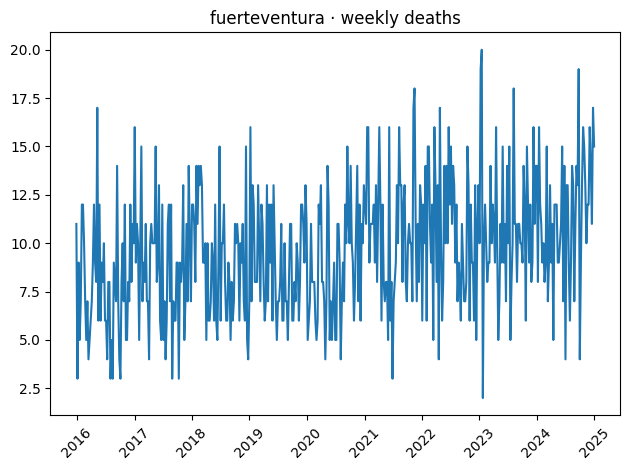

Saved figure -> C:\dev\projects\climate_mortality\reports\islands\figures\fuerteventura\ftv_eda01_weekly_tmax_timeseries.png


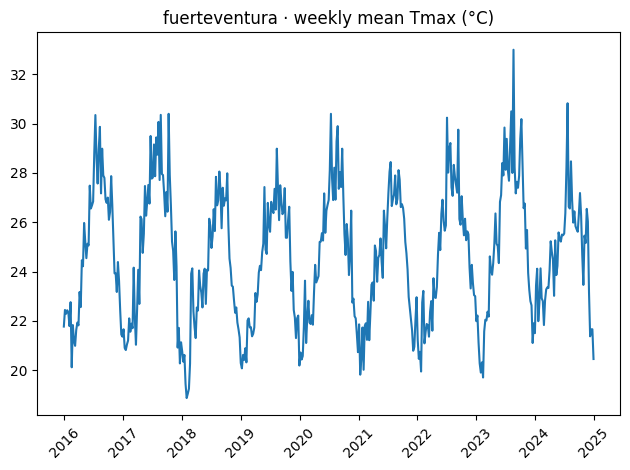

In [6]:
plt.figure()
plt.plot(df["week_start"], df["deaths_week"])
plt.title(f"{ISLAND_NAME} · weekly deaths")
plt.xticks(rotation=45)
plt.tight_layout()
autosave_fig(plt.gcf(), FIG_DIR, f"{ISLAND_CODE}_eda01_weekly_deaths_timeseries.png")
plt.show()

plt.figure()
plt.plot(df["week_start"], df["tmax_c_mean"])
plt.title(f"{ISLAND_NAME} · weekly mean Tmax (°C)")
plt.xticks(rotation=45)
plt.tight_layout()
autosave_fig(plt.gcf(), FIG_DIR, f"{ISLAND_CODE}_eda01_weekly_tmax_timeseries.png")
plt.show()


## 5. Temperature and mortality
### 5.1 Absolute temperature vs deaths
Absolute temperature can be heavily confounded by seasonality.


Saved figure -> C:\dev\projects\climate_mortality\reports\islands\figures\fuerteventura\ftv_eda01_deaths_vs_absolute_tmax_scatter.png


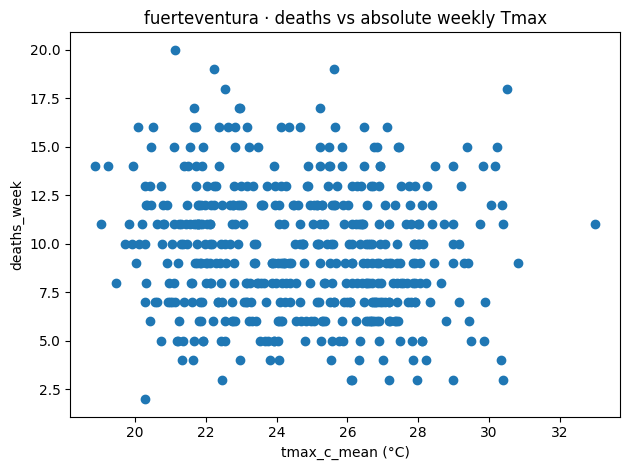

corr(deaths, tmax_c_mean): -0.107


In [7]:
plt.figure()
plt.scatter(df["tmax_c_mean"], df["deaths_week"])
plt.xlabel("tmax_c_mean (°C)")
plt.ylabel("deaths_week")
plt.title(f"{ISLAND_NAME} · deaths vs absolute weekly Tmax")
plt.tight_layout()
autosave_fig(plt.gcf(), FIG_DIR, f"{ISLAND_CODE}_eda01_deaths_vs_absolute_tmax_scatter.png")
plt.show()

corr_abs = df[["deaths_week", "tmax_c_mean"]].corr().iloc[0, 1]
print("corr(deaths, tmax_c_mean):", round(float(corr_abs), 4))


##### 5.2 Temperature anomaly vs deaths
Use anomalies (relative temperature) to reduce seasonal confounding.


Saved figure -> C:\dev\projects\climate_mortality\reports\islands\figures\fuerteventura\ftv_eda01_deaths_vs_temperature_anomaly_scatter.png


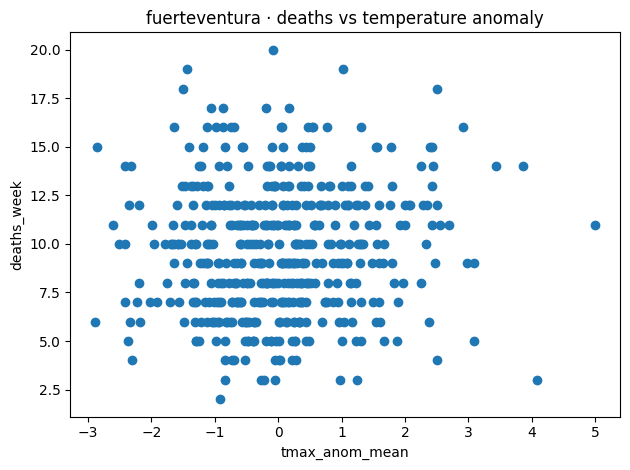

corr(deaths, tmax_anom_mean): 0.0742


In [8]:
anom_col = None
for c in ["tmax_anom_mean_week", "tmax_anom_mean", "tmax_anom_c_mean", "tmax_anom"]:
    if c in df.columns:
        anom_col = c
        break

if anom_col is None:
    print("No anomaly column found in this master. (Skip or create anomalies upstream.)")
else:
    plt.figure()
    plt.scatter(df[anom_col], df["deaths_week"])
    plt.xlabel(anom_col)
    plt.ylabel("deaths_week")
    plt.title(f"{ISLAND_NAME} · deaths vs temperature anomaly")
    plt.tight_layout()
    autosave_fig(plt.gcf(), FIG_DIR, f"{ISLAND_CODE}_eda01_deaths_vs_temperature_anomaly_scatter.png")
    plt.show()
    corr_anom = df[["deaths_week", anom_col]].corr().iloc[0, 1]
    print(f"corr(deaths, {anom_col}):", round(float(corr_anom), 4))


### 5.3 Extreme heat (p90 / p95)
Compare weeks above an extreme threshold vs the rest.


In [9]:
q90_tmax = df["tmax_c_mean"].quantile(0.90)
q95_tmax = df["tmax_c_mean"].quantile(0.95)

df["heat_p90"] = (df["tmax_c_mean"] >= q90_tmax).astype(int)
df["heat_p95"] = (df["tmax_c_mean"] >= q95_tmax).astype(int)

print(f"Official heat thresholds from tmax_c_mean -> p90={q90_tmax:.2f}, p95={q95_tmax:.2f}")
print(df["heat_p95"].value_counts(dropna=False))

tab_p95 = df.groupby("heat_p95")["deaths_week"].agg(["count", "mean", "median"])
display(tab_p95)

if 0 in tab_p95.index and 1 in tab_p95.index:
    delta_p95 = float(tab_p95.loc[1, "mean"] - tab_p95.loc[0, "mean"])
    print("Δ deaths (heat_p95 vs baseline):", round(delta_p95, 2))

save_table(tab_p95.reset_index(), TAB_DIR, f"heat_p95_deaths_{ISLAND_CODE}.csv", index=False)


Official heat thresholds from tmax_c_mean -> p90=27.99, p95=28.99
heat_p95
0    445
1     26
Name: count, dtype: int64


,count,mean,median
heat_p95,,,
0,445,9.588764,9.0
1,26,10.153846,10.5


Δ deaths (heat_p95 vs baseline): 0.57
Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\fuerteventura\heat_p95_deaths_ftv.csv


WindowsPath('C:/dev/projects/climate_mortality/reports/islands/tables/fuerteventura/heat_p95_deaths_ftv.csv')

## 6. Calima and mortality
Analyze calima intensity proxies vs weekly deaths.

### 6.1 Calima proxy audit
Validate the merged calima proxy coverage and weekly level distribution before using it in downstream comparisons.


,missing,missing_pct
calima_proxy_score_v2,0,0.0
calima_proxy_level_v2,0,0.0


Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\fuerteventura\calima_proxy_audit_missing_ftv.csv


,calima_proxy_level_v2,weeks
0,possible,230
1,no_calima,136
2,probable,73
3,intense,32


Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\fuerteventura\calima_proxy_level_counts_ftv.csv
Saved figure -> C:\dev\projects\climate_mortality\reports\islands\figures\fuerteventura\ftv_eda01_calima_proxy_level_counts.png


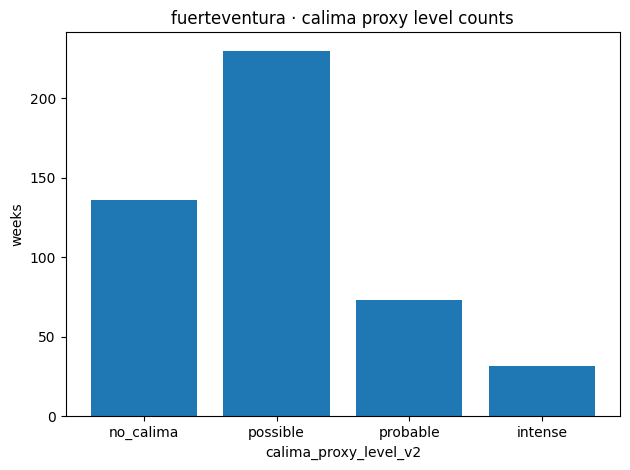

CAP yellow alignment with proxy (probable+intense among CAP yellow): 0.6667


In [10]:
proxy_cols = ["calima_proxy_score_v2", "calima_proxy_level_v2"]
have_proxy = all(c in df.columns for c in proxy_cols)

if have_proxy:
    proxy_na = df[proxy_cols].isna().sum().rename("missing").to_frame()
    proxy_na["missing_pct"] = (proxy_na["missing"] / len(df)).round(4)
    display(proxy_na)
    save_table(proxy_na.reset_index().rename(columns={"index": "column"}), TAB_DIR, f"calima_proxy_audit_missing_{ISLAND_CODE}.csv", index=False)

    proxy_counts = (
        df["calima_proxy_level_v2"]
        .value_counts(dropna=False)
        .rename_axis("calima_proxy_level_v2")
        .reset_index(name="weeks")
    )
    display(proxy_counts)
    save_table(proxy_counts, TAB_DIR, f"calima_proxy_level_counts_{ISLAND_CODE}.csv", index=False)

    plot_counts = df["calima_proxy_level_v2"].dropna().value_counts()
    if not plot_counts.empty:
        desired_order = ["no_calima", "possible", "probable", "intense"]
        plot_counts = plot_counts.reindex([x for x in desired_order if x in plot_counts.index])

        plt.figure()
        plt.bar(plot_counts.index.astype(str), plot_counts.values)
        plt.title(f"{ISLAND_NAME} · calima proxy level counts")
        plt.xlabel("calima_proxy_level_v2")
        plt.ylabel("weeks")
        plt.tight_layout()
        autosave_fig(plt.gcf(), FIG_DIR, f"{ISLAND_CODE}_eda01_calima_proxy_level_counts.png")
        plt.show()

    if {"cap_dust_yellow_plus_week", "calima_proxy_level_v2"}.issubset(df.columns):
        tmp = df.copy()
        tmp["proxy_ge_probable"] = tmp["calima_proxy_level_v2"].isin(["probable", "intense"])
        cap_yellow = tmp["cap_dust_yellow_plus_week"] == 1
        alignment = tmp.loc[cap_yellow, "proxy_ge_probable"].mean()
        print("CAP yellow alignment with proxy (probable+intense among CAP yellow):", round(float(alignment), 4))
else:
    print("No calima proxy level column found in this master.")


### 6.2 Calima levels and deaths
Compare weekly deaths across calima proxy levels (or DAI fallback if proxy columns are unavailable).


In [11]:
if "calima_proxy_level_v2" in df.columns:
    cal = df.groupby("calima_proxy_level_v2")["deaths_week"].agg(["count", "mean", "median"])
    level_order = ["no_calima", "possible", "probable", "intense"]
    cal = cal.reindex([x for x in level_order if x in cal.index])
    display(cal)
    save_table(cal.reset_index(), TAB_DIR, f"calima_proxy_level_v2_deaths_{ISLAND_CODE}.csv", index=False)
else:
    print("No calima_proxy_level_v2. Using calima_dai_flag if available...")
    if "calima_dai_flag" in df.columns:
        cal = df.groupby("calima_dai_flag")["deaths_week"].agg(["count", "mean", "median"]).sort_index()
        display(cal)
        save_table(cal.reset_index(), TAB_DIR, f"calima_dai_flag_deaths_{ISLAND_CODE}.csv", index=False)


,count,mean,median
calima_proxy_level_v2,,,
no_calima,136,9.823529,9.5
possible,230,9.569565,9.5
probable,73,9.205479,9.0
intense,32,10.062500,10.5


Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\fuerteventura\calima_proxy_level_v2_deaths_ftv.csv


## 7. Interaction: extreme heat × calima
A simple 2×2 cross-tab.


In [12]:
tmp = df.copy()

if "calima_proxy_level_v2" in tmp.columns:
    tmp["calima_intense"] = (tmp["calima_proxy_level_v2"] == "intense").astype(int)
else:
    tmp["calima_intense"] = 0

# 2x2 count table to verify whether joint exposure exists
ct = pd.crosstab(tmp["heat_p95"], tmp["calima_intense"], dropna=False)
display(ct)

joint_n = ((tmp["heat_p95"] == 1) & (tmp["calima_intense"] == 1)).sum()
print(f"Weeks with heat_p95=1 and calima_intense=1: {joint_n}")

# Descriptive mortality summary by joint exposure group
inter = (
    tmp.groupby(["heat_p95", "calima_intense"])["deaths_week"]
       .agg(["count", "mean", "median"])
       .reindex(pd.MultiIndex.from_product([[0, 1], [0, 1]],
                                           names=["heat_p95", "calima_intense"]))
)

inter["count"] = inter["count"].fillna(0).astype(int)

display(inter)

save_table(ct.reset_index(), TAB_DIR, f"interaction_counts_heat_p95_x_calima_intense_{ISLAND_CODE}.csv", index=False)
save_table(inter.reset_index(), TAB_DIR, f"interaction_heat_p95_x_calima_intense_{ISLAND_CODE}.csv", index=False)


calima_intense,0,1
heat_p95,,
0,416,29
1,23,3


Weeks with heat_p95=1 and calima_intense=1: 3


count       mean  median
heat_p95 calima_intense                          
0        0                 416   9.540865     9.0
         1                  29  10.275862    11.0
1        0                  23  10.434783    11.0
         1                   3   8.000000     9.0

Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\fuerteventura\interaction_counts_heat_p95_x_calima_intense_ftv.csv
Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\fuerteventura\interaction_heat_p95_x_calima_intense_ftv.csv


WindowsPath('C:/dev/projects/climate_mortality/reports/islands/tables/fuerteventura/interaction_heat_p95_x_calima_intense_ftv.csv')

### Key numbers to report
- Δ deaths (heat p95 vs baseline): **0.57**
- Δ deaths (calima intense vs no_calima): **+0.24 deaths/week**
- Proxy coverage / missingness: **0.00%**
- CAP yellow alignment with proxy: **0.6667**
- corr(deaths, tmax_c_mean): **-0.107**
- corr(deaths, Tmax anomaly): **0.0742**

#### Summary
Overall, the Fuerteventura audit/EDA passes the main quality checks. week_start parses correctly, no duplicate weekly keys were found, and no negative death counts were detected. Weekly mortality coverage is complete in this dataset, which is a clear strength. However, several environmental variables remain incomplete: CAP-based heat and dust indicators are only available for 342 of 471 weeks (about 72.6%), while calima_level_week and calima_dai_flag are missing for roughly 31.0% of the series. PM2.5, SO2, and NO2 also show some missingness, although the v2 calima proxy is fully complete.

From a descriptive perspective, the weekly heat signal appears present but weak. The p95 threshold for weekly Tmax is 28.99°C, and extreme heat weeks show slightly higher mean mortality than baseline weeks (10.15 vs 9.59 deaths/week; Δ = +0.57). At the same time, simple correlations remain small: deaths are weakly negatively correlated with absolute Tmax and only weakly positively correlated with Tmax anomaly. This suggests that any heat-related signal at weekly resolution is modest and should be interpreted cautiously.

The calima signal also appears limited in this weekly exploratory view. Mean weekly deaths are only slightly higher in intense calima weeks than in no_calima weeks (10.06 vs 9.82 deaths/week), which does not point to a strong standalone calima pattern in Fuerteventura. In addition, CAP yellow alignment with the proxy is moderate rather than especially strong, which further supports a cautious interpretation.

The joint exposure analysis is particularly constrained. Only 3 weeks in the full series are classified as both heat_p95=1 and calima_intense=1, which is far too few to support any meaningful interpretation of interaction or compound effects between extreme heat and intense calima at weekly resolution.

In summary, Fuerteventura shows a weak-to-modest weekly heat signal and only a limited descriptive calima signal, with the main constraints being incomplete environmental coverage and the very small number of joint extreme exposure weeks. Any conclusions should therefore remain exploratory and comparative rather than inferential.